# Задание

In [860]:
# ДЗ 3
# 1. Для изображения sar_3.jpg найти наиболее протяженный участок (выделить линии при помощи преобразования Хафа)
# 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

# 1. Для изображения sar_3.jpg найти наиболее протяженный участок (выделить линии при помощи преобразования Хафа)

In [861]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math

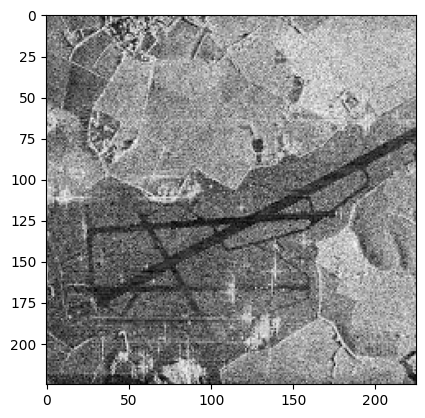

In [862]:
image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")
plt.show()

In [863]:
blurred = cv2.GaussianBlur(image_gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150, apertureSize=3)

lines_prob= cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=100, minLineLength=100, maxLineGap=10)
lines_basic = cv2.HoughLines(edges, 1, np.pi / 180, 120)

In [864]:
def clip_line_to_image(pt1, pt2, img_shape):
    h, w = img_shape[:2]
    ret, clipped_pt1, clipped_pt2 = cv2.clipLine((0, 0, w, h), pt1, pt2)
    if ret:
        return clipped_pt1, clipped_pt2
    else:
        return pt1, pt2

In [865]:
# Find longest line HoughLines basic
longest_line_basic = None
max_length_basic = 0

if lines_basic is not None:
    for i in range(0, len(lines_basic)):
        rho = lines_basic[i][0][0]
        theta = lines_basic[i][0][1]
        a = math.cos(theta)
        b = math.sin(theta)
        x0 = a * rho
        y0 = b * rho
        pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
        pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
        pt1, pt2 = clip_line_to_image(pt1, pt2, image.shape )
        
        length = np.sqrt((pt2[0] - pt1[0])**2 + (pt2[1] - pt1[1])**2)
        if length > max_length_basic:
            max_length_basic = length
            longest_line_basic = (pt1, pt2)

# Draw longest line
image_longest_line_basic = image.copy()
if longest_line_basic is not None:
    pt1, pt2 = longest_line_basic
    cv2.line(image_longest_line_basic, pt1, pt2, (0, 0, 255), 3, cv2.LINE_AA)

In [866]:
# Find longest line HoughLines probabilistic
longest_line_prob = None
max_length_prob = 0

for line in lines_prob:
    x1, y1, x2, y2 = line[0]
    length = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
    if length > max_length_prob:
        max_length_prob = length
        longest_line_prob = line

# Draw longest line
image_longest_line_prob = image.copy()
if longest_line_prob is not None:
    x1, y1, x2, y2 = longest_line_prob[0]
    cv2.line(image_longest_line_prob, (x1, y1), (x2, y2), (0, 255, 0), 3, cv2.LINE_AA)

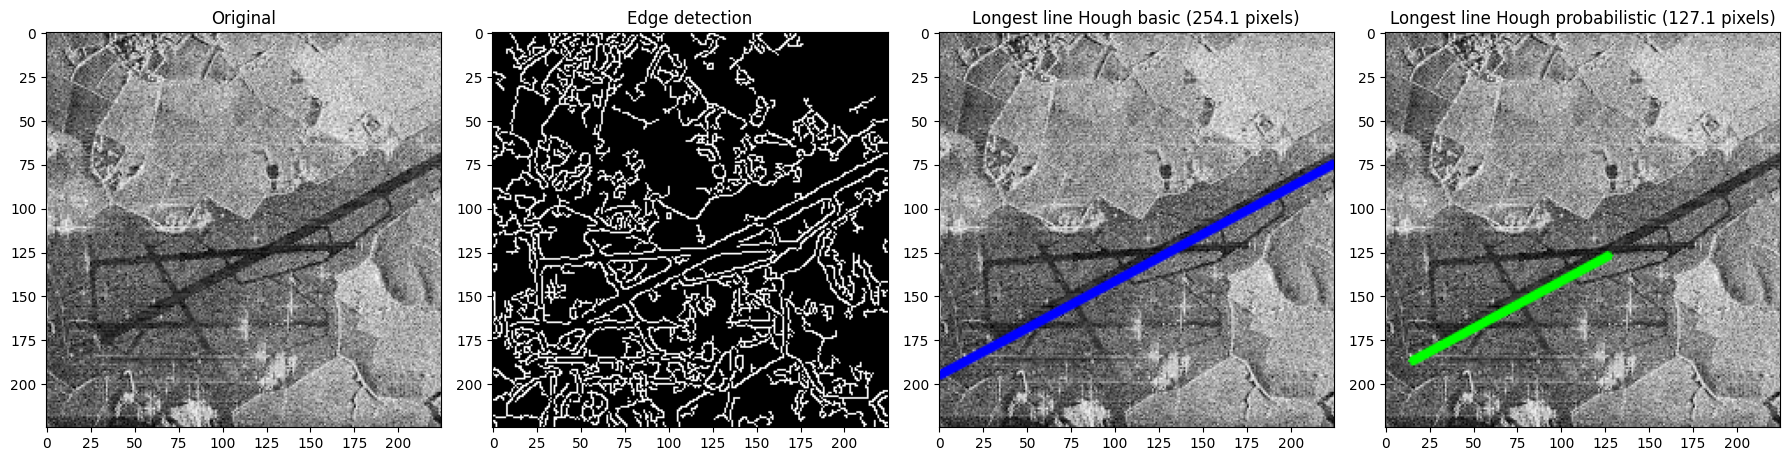

Longest line Hough basic
	Lenght: 254.1 pixels
	Coordinates: (0, 195) - (224, 75)
Longest line Hough probabilistic
	Lenght: 127.1 pixels
	Coordinates: (15, 187) - (127, 127)


In [867]:
images = {
    "Original": image_gray,
    "Edge detection": edges,
    f"Longest line Hough basic ({max_length_basic:.1f} pixels)": image_longest_line_basic,
    f"Longest line Hough probabilistic ({max_length_prob:.1f} pixels)": image_longest_line_prob,
}

# Show images
fig, axs = plt.subplots(1, 4, figsize=(18, 5))

col = 0
for col, (key, img) in enumerate(images.items()):
    axs[col].imshow(img, cmap='gray')
    axs[col].set_title(key)

plt.tight_layout()
plt.show()

# Metrics
if longest_line_basic is not None:
    print(f"Longest line Hough basic")
    print(f"\tLenght: {max_length_basic:.1f} pixels")
    print(f"\tCoordinates: {str(longest_line_basic[0])} - {str(longest_line_basic[1])}")

if longest_line_prob is not None:
    print(f"Longest line Hough probabilistic")
    print(f"\tLenght: {max_length_prob:.1f} pixels")
    x1, y1, x2, y2 = longest_line_prob[0]
    print(f"\tCoordinates: ({x1}, {y1}) - ({x2}, {y2})")

# 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

In [868]:
from copy import deepcopy

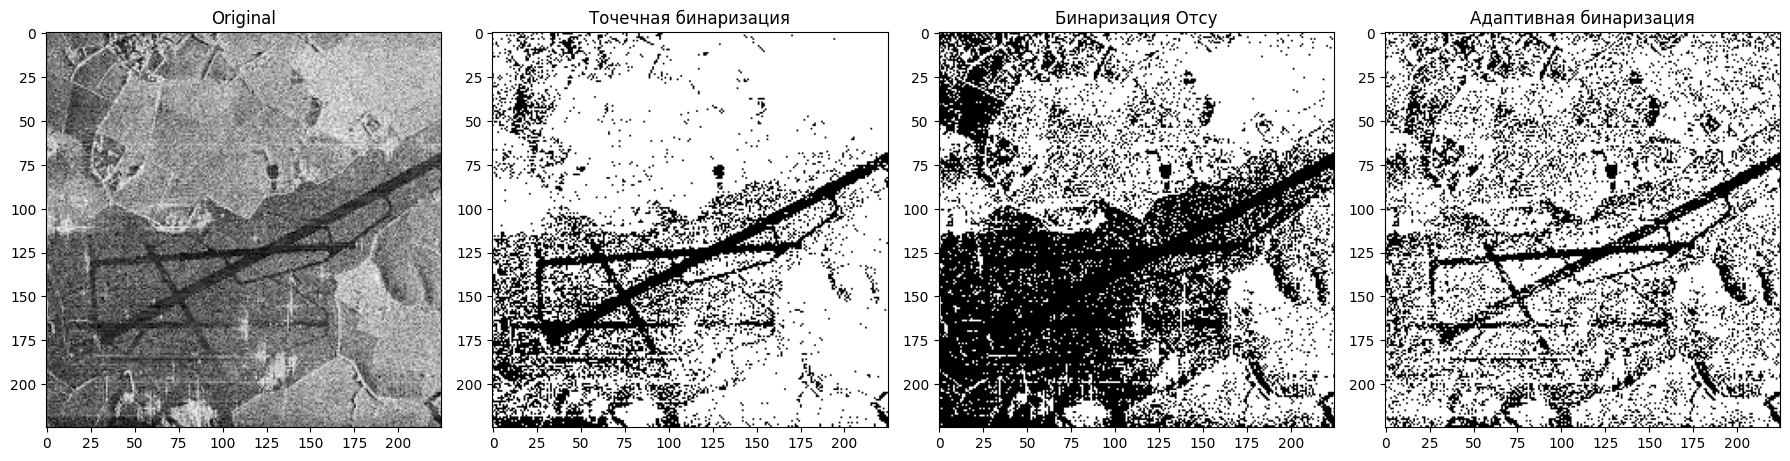

In [869]:
images = {"Original": image_gray}

# Точечная бинаризация
bin_img = deepcopy(image_gray)
T  = 90
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255
images["Точечная бинаризация"] = bin_img

# Бинаризация Отсу
_, th2 = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
images["Бинаризация Отсу"] = th2

# Адаптивная бинаризация
th3 = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                            cv2.THRESH_BINARY, 71, 21)
images["Адаптивная бинаризация"] = th3


# Show images
fig, axs = plt.subplots(1, 4, figsize=(18, 5))

col = 0
for col, (key, img) in enumerate(images.items()):
    axs[col].imshow(img, cmap='gray')
    axs[col].set_title(key)

plt.tight_layout()
plt.show()

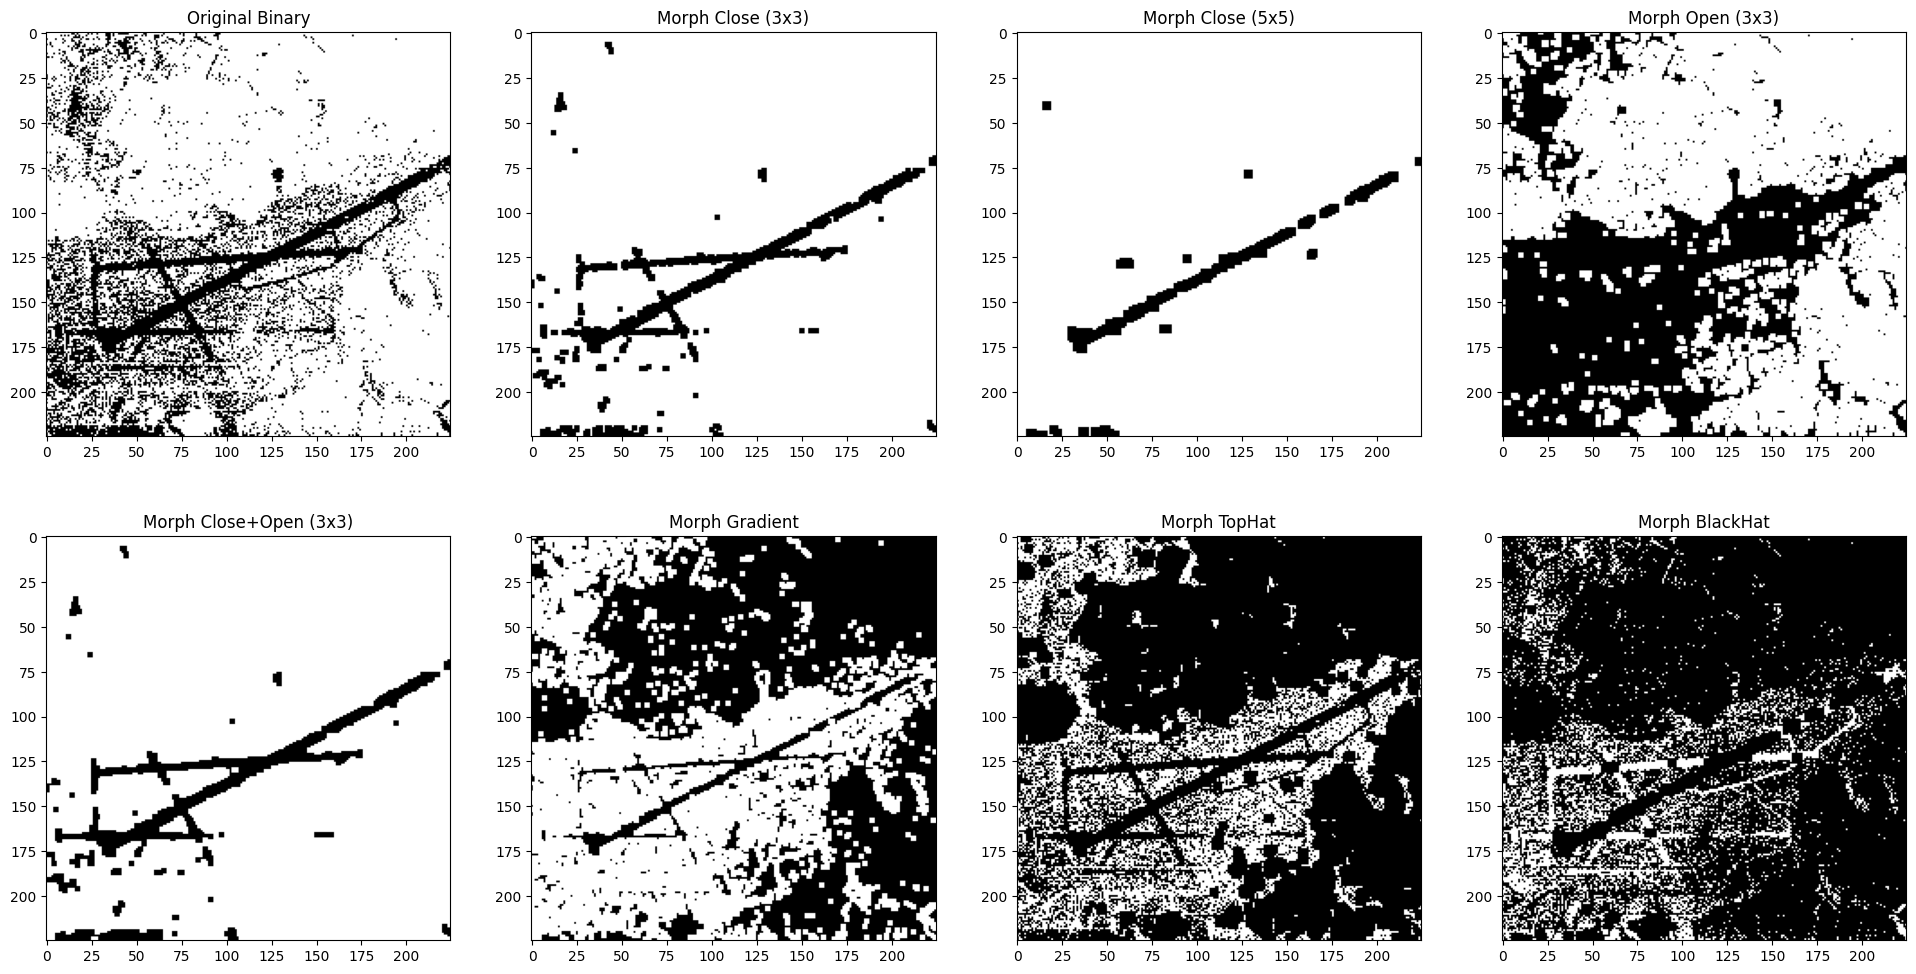

In [870]:
morph_ops = {
    "Original Binary": bin_img,
    
    "Morph Close (3x3)": cv2.morphologyEx(bin_img, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8)),
    "Morph Close (5x5)": cv2.morphologyEx(bin_img, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8)),
    "Morph Open (3x3)": cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, np.ones((3,3), np.uint8)),

    "Morph Close+Open (3x3)": cv2.morphologyEx(cv2.morphologyEx(bin_img, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8)), cv2.MORPH_OPEN, np.ones((3,3), np.uint8)),
    "Morph Gradient": cv2.morphologyEx(bin_img, cv2.MORPH_GRADIENT, np.ones((3,3), np.uint8)),
    "Morph TopHat": cv2.morphologyEx(bin_img, cv2.MORPH_TOPHAT, np.ones((5,5), np.uint8)),
    "Morph BlackHat": cv2.morphologyEx(bin_img, cv2.MORPH_BLACKHAT, np.ones((5,5), np.uint8))
}

# Show morphological operations
fig, axs = plt.subplots(2, 4, figsize=(24, 12))

for i, (key, img) in enumerate(morph_ops.items()):
    row, col = i // 4, i % 4
    axs[row, col].imshow(img, cmap='gray')
    axs[row, col].set_title(key)

plt.show()

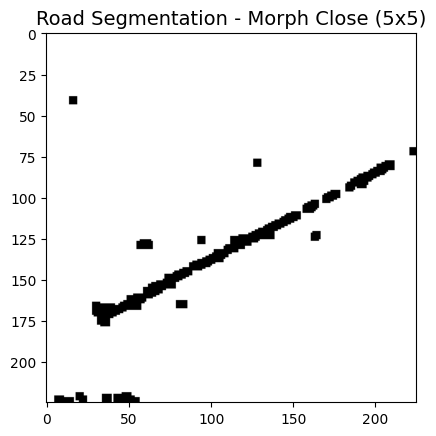

In [871]:
main_road = cv2.morphologyEx(bin_img, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8))

plt.imshow(main_road, cmap="gray")
plt.title('Road Segmentation - Morph Close (5x5)', fontsize=14)
plt.show()